<a href="https://colab.research.google.com/github/Saiful-2/notebooks/blob/main/SUB_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **House Price Prediction using Linear Regression**
1. Import Required Libraries

In [1]:
# ============================================
# Step 1: Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# ============================================
# Step 2: Load Dataset
# ============================================

url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/House%20Price%20Prediction%20Dataset.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [3]:
# ============================================
# Step 3: Explore Dataset
# ============================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(2000, 10)

Column Names:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None

Missing Values:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price    

In [4]:
# ============================================
# Step 4: Select Features and Target Variable
# ============================================

# Input Features
X = df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']]

# Target Variable
y = df['Price']

print("\nSelected Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())



Selected Features:
   Area  Bedrooms  Bathrooms  Floors  YearBuilt
0  1360         5          4       3       1970
1  4272         5          4       3       1958
2  3592         2          2       3       1938
3   966         4          2       2       1902
4  4926         1          4       2       1975

Target Variable:
0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64


In [5]:
# ============================================
# Step 5: Split Dataset into Training and Testing Sets
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 5)
Testing Data Shape: (400, 5)


In [6]:
# ============================================
# Step 6: Apply Linear Regression
# ============================================

model = LinearRegression()

In [7]:
# ============================================
# Step 7: Train the Model
# ============================================

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [8]:
# ============================================
# Step 8: Predict House Prices
# ============================================

y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred[:10])

Predicted Prices:
[515577.20094333 544286.23995207 504412.67222196 555773.69096497
 568830.77263034 550559.76495508 551103.35655728 545058.55449332
 563718.90528357 569110.12168438]


In [9]:
# ============================================
# Step 9: Evaluate Model Performance
# ============================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)


Model Evaluation
MAE  : 244587.1999197856
MSE  : 78789724000.88458
RMSE : 280695.0729900412
R² Score : -0.01273663755401877


In [10]:
# ============================================
# Step 10: Compare Actual vs Predicted Prices
# ============================================

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0        514764    515577.200943
1        694256    544286.239952
2         66375    504412.672222
3        650243    555773.690965
4        223285    568830.772630
5        468127    550559.764955
6        513002    551103.356557
7        911525    545058.554493
8        723265    563718.905284
9        339416    569110.121684


In [11]:
# ============================================
# Step 11: Predict Price for a New House
# ============================================

new_house = pd.DataFrame({
    'Area': [2500],
    'Bedrooms': [4],
    'Bathrooms': [3],
    'Floors': [2],
    'YearBuilt': [2018]
})

predicted_price = model.predict(new_house)

print("\nPredicted House Price:")
print(predicted_price[0])


Predicted House Price:
538078.7147250394


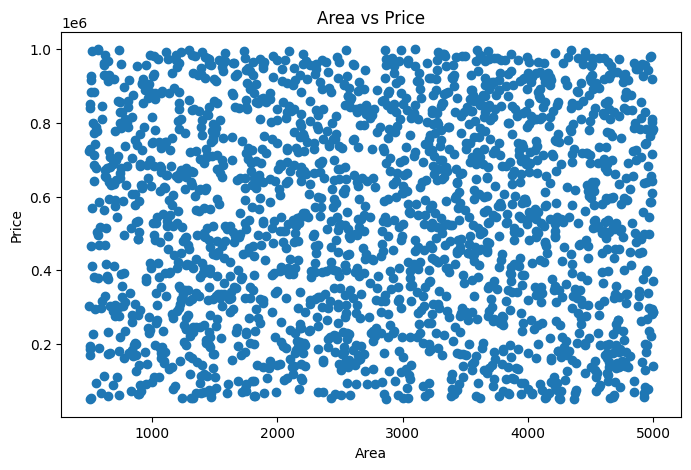

In [12]:
# ============================================
# Step 12: Feature vs Price Plot (Area vs Price)
# ============================================

plt.figure(figsize=(8,5))
plt.scatter(df['Area'], df['Price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

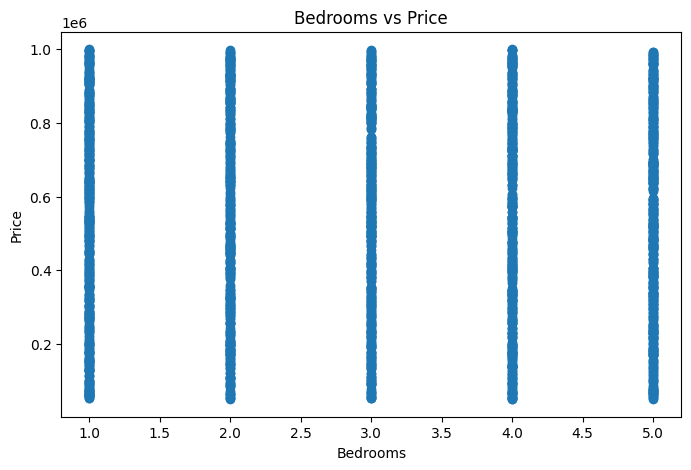

In [13]:
# ============================================
# Step 13: Feature vs Price Plot (Bedrooms vs Price)
# ============================================

plt.figure(figsize=(8,5))
plt.scatter(df['Bedrooms'], df['Price'])
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Bedrooms vs Price")
plt.show()

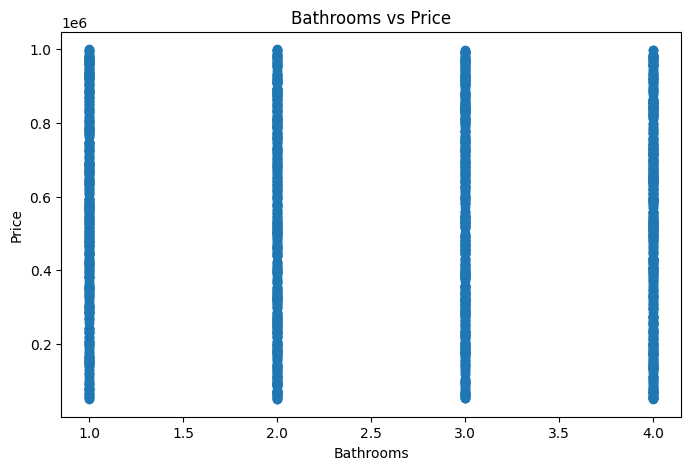

In [14]:
# ============================================
# Step 14: Feature vs Price Plot (Bathrooms vs Price)
# ============================================

plt.figure(figsize=(8,5))
plt.scatter(df['Bathrooms'], df['Price'])
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.title("Bathrooms vs Price")
plt.show()

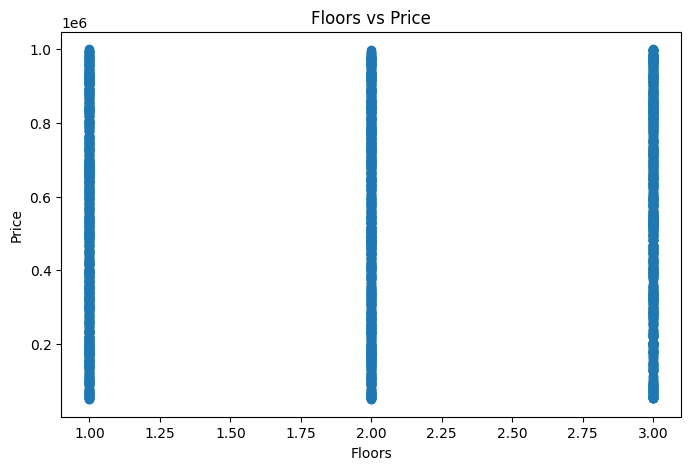

In [15]:
# ============================================
# Step 15: Feature vs Price Plot (Floors vs Price)
# ============================================

plt.figure(figsize=(8,5))
plt.scatter(df['Floors'], df['Price'])
plt.xlabel("Floors")
plt.ylabel("Price")
plt.title("Floors vs Price")
plt.show()

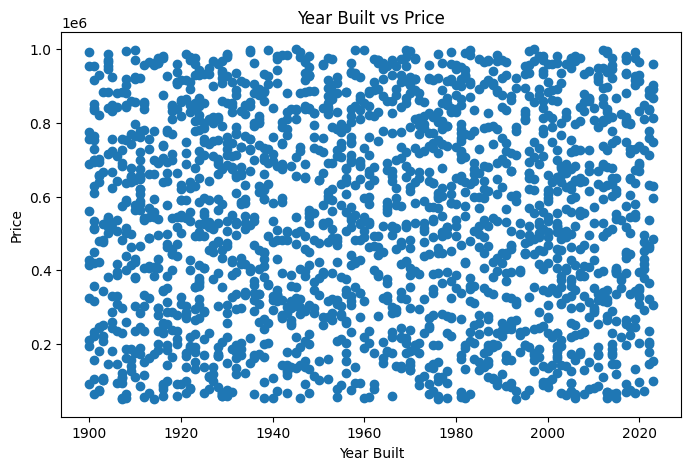

In [16]:
# ============================================
# Step 16: Feature vs Price Plot (YearBuilt vs Price)
# ============================================

plt.figure(figsize=(8,5))
plt.scatter(df['YearBuilt'], df['Price'])
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.title("Year Built vs Price")
plt.show()

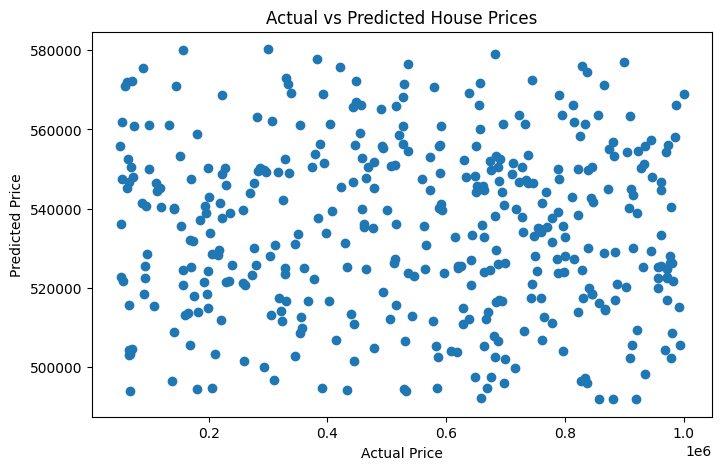

In [17]:
# ============================================
# Step 17: Actual vs Predicted Price Plot
# ============================================

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [18]:
# ============================================
# End of Project
# ============================================

print("House Price Prediction Project Completed Successfully")

House Price Prediction Project Completed Successfully
